# Paper Replication: Mullen / Kothe / Chang — Artifact Subspace Reconstruction

Walkthrough of **Artifact Subspace Reconstruction (ASR)** based on:

- **Mullen et al. (2013, 2015)** — *Real-time modeling and 3D visualization of source dynamics and connectivity using wearable EEG*. IEEE EMBC; IEEE TBME 62(11):2553-2567. — original method.
- **Kothe** — *The Artifact Subspace Reconstruction Method*. Canonical algorithm note. — formal description.
- **Chang et al. (2020)** — *Evaluation of artifact subspace reconstruction for automatic artifact components removal in multi-channel EEG recordings*. IEEE TBME 67(4):1114-1121. — systematic evaluation, established the **k = 20-30** cutoff recommendation.

This notebook reproduces the core ASR algorithm steps on synthetic EEG, then sweeps the cutoff parameter to recreate the trade-off shown in Chang 2020 Figure 2a. We use `mne_denoise.asr.ASR`, which wraps the same calibration and burst-repair pipeline as EEGLAB's `clean_rawdata`.

In [1]:
import matplotlib.pyplot as plt
import mne
import numpy as np

from mne_denoise.asr import ASR, compute_asr_qa_metrics

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(42)
mne.set_log_level("WARNING")

## 1. Generate Synthetic EEG with Burst Artifacts

ASR is designed for short, high-amplitude, spatially-structured artifacts (electrode bumps, muscle bursts, etc.). We simulate:

- 32-channel, 60 s recording at 250 Hz with a 1/f background plus a 10 Hz alpha rhythm.
- Eight burst artifacts of 0.5 s each, evenly spaced, with a random spatial direction and 12× the typical channel std (matching the validation paradigm).

Keeping the clean background and noisy versions side-by-side lets us (a) hand ASR the clean version as an explicit calibration segment (Kothe's recommended best practice — see Section 4) and (b) measure how much of the burst ASR repairs vs how much of the clean background it leaves alone.

In [2]:
sfreq = 250.0
n_channels = 32
duration_s = 60.0
n_times = int(duration_s * sfreq)
t = np.arange(n_times) / sfreq

# 1/f background per channel (Welch shaping in time domain).
background = rng.standard_normal((n_channels, n_times))
background = np.cumsum(background, axis=1) / np.sqrt(np.arange(1, n_times + 1))
background -= background.mean(axis=1, keepdims=True)

# Common alpha rhythm at 10 Hz, mixed into the first ~half of channels.
alpha = 0.6 * np.sin(2 * np.pi * 10.0 * t)
mix = np.concatenate(
    [np.linspace(1.0, 0.2, n_channels // 2), np.zeros(n_channels - n_channels // 2)]
)
background += mix[:, None] * alpha[None, :]

# Scale to ~ uV-magnitude EEG, then add bursts to a copy.
channel_std = np.std(background, axis=1).mean()
background *= 10e-6 / channel_std  # ~10 uV per channel

n_bursts = 8
burst_len = int(0.5 * sfreq)
burst_mask = np.zeros(n_times, dtype=bool)
starts = np.linspace(2 * sfreq, n_times - 2 * sfreq - burst_len, n_bursts).astype(int)
noisy = background.copy()
amplitude = 12.0
for start in starts:
    stop = start + burst_len
    spatial = rng.standard_normal(n_channels)
    spatial /= np.linalg.norm(spatial)
    temporal = rng.standard_normal(burst_len) + 0.5 * np.sin(
        np.linspace(0, 6 * np.pi, burst_len)
    )
    noisy[:, start:stop] += amplitude * 10e-6 * np.outer(spatial, temporal)
    burst_mask[start:stop] = True

ch_names = [f"EEG{i:02d}" for i in range(n_channels)]
info = mne.create_info(ch_names, sfreq, "eeg")
raw_clean = mne.io.RawArray(background, info)
raw_noisy = mne.io.RawArray(noisy, info)
print(f"Clean RMS:    {np.sqrt(np.mean(background**2)) * 1e6:.2f} uV")
print(f"Noisy RMS:    {np.sqrt(np.mean(noisy**2)) * 1e6:.2f} uV")
print(f"Burst frac:   {burst_mask.mean() * 100:.1f}% of samples")

Clean RMS:    10.62 uV
Noisy RMS:    12.02 uV
Burst frac:   6.7% of samples


Plot the first 10 seconds — bursts are visible as wide-band excursions across channels.

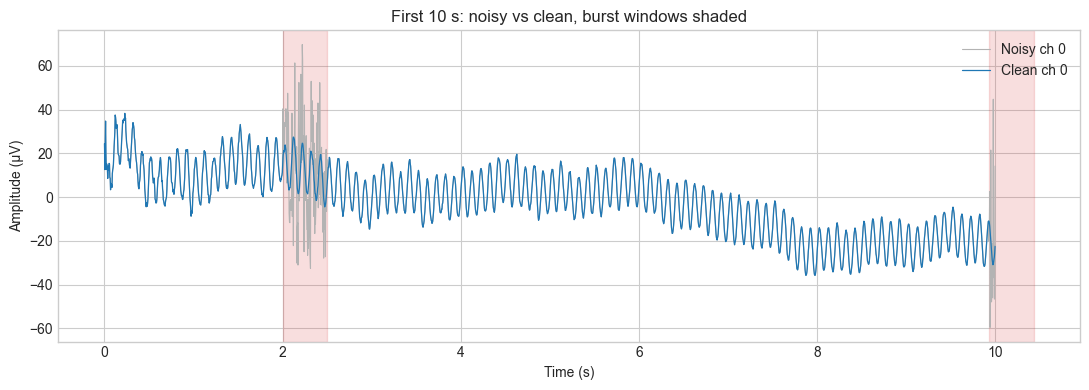

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
preview = slice(0, int(10 * sfreq))
ax.plot(t[preview], noisy[0, preview] * 1e6, color="0.7", lw=0.8, label="Noisy ch 0")
ax.plot(
    t[preview], background[0, preview] * 1e6, color="C0", lw=0.9, label="Clean ch 0"
)
for s in starts:
    if s < 10 * sfreq:
        ax.axvspan(s / sfreq, (s + burst_len) / sfreq, color="C3", alpha=0.15)
ax.set(
    xlabel="Time (s)",
    ylabel="Amplitude (µV)",
    title="First 10 s: noisy vs clean, burst windows shaded",
)
ax.legend(loc="upper right")
fig.tight_layout();

## 2. ASR Algorithm: Calibration + Burst Repair

ASR runs in two phases:

1. **Calibration** — automatically find clean reference windows (`clean_windows`), estimate a robust covariance matrix **C** of the reference data via the geometric median of per-block covariances, derive the **mixing matrix M** as `sqrtm(C)`, and fit a per-component RMS threshold from a truncated generalized Gaussian.
2. **Burst repair** — slide a short window across the data, eigendecompose each window's covariance, mark components whose RMS exceeds `μ + k·σ`, zero those columns of `V^T · M`, and reconstruct via:

$$X_{\text{clean}} = M \, (V^T_{\text{clean}} M)^+ \, V^T \, X$$

where the pseudo-inverse spreads the rejected-component energy back into the retained subspace using the calibration mixing matrix. Successive reconstruction matrices are blended with a raised-cosine window to avoid edge transients.

Below we use the Chang 2020 recommended `cutoff=20`. Per Kothe, ASR is most reliable when given an explicit clean calibration segment (e.g. 1 min of resting baseline). Here we pass the burst-free `raw_clean` as calibration; in real recordings you would use a baseline / eyes-closed block of the same session.

In [4]:
asr = ASR(cutoff=20.0, picks="eeg", calibration="manual", verbose=False)
asr.fit(raw_noisy, calibration=raw_clean)
raw_repaired = asr.transform(raw_noisy)

metrics = compute_asr_qa_metrics(raw_noisy, raw_repaired, asr)
print(
    f"Reconstructed samples:         "
    f"{metrics['fraction_reconstructed_samples'] * 100:.1f}%"
)
print(
    f"Reconstructed windows:         "
    f"{metrics['fraction_reconstructed_windows'] * 100:.1f}%"
)
print(
    f"Mean components reconstructed: "
    f"{metrics['mean_components_reconstructed']:.2f} / {n_channels}"
)
print(
    f"Max components reconstructed:  "
    f"{metrics['max_components_reconstructed']} / {n_channels}"
)

C:\Users\s\AppData\Local\Temp\ipykernel_43884\1233283444.py:2: UserWarning: ASR assumes high-pass filtered data; input info reports highpass=0.0 Hz.
  asr.fit(raw_noisy, calibration=raw_clean)


C:\Users\s\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_set_output.py:316: UserWarning: ASR assumes high-pass filtered data; input info reports highpass=0.0 Hz.
  data_to_wrap = f(self, X, *args, **kwargs)


Reconstructed samples:         73.5%
Reconstructed windows:         69.0%
Mean components reconstructed: 0.76 / 32
Max components reconstructed:  2 / 32


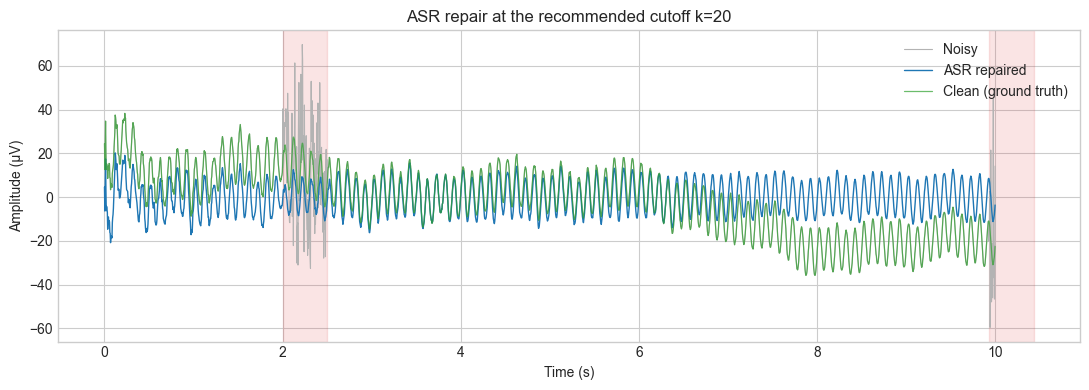

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
repaired_arr = raw_repaired.get_data()
ax.plot(t[preview], noisy[0, preview] * 1e6, color="0.7", lw=0.8, label="Noisy")
ax.plot(
    t[preview], repaired_arr[0, preview] * 1e6, color="C0", lw=1.0, label="ASR repaired"
)
ax.plot(
    t[preview],
    background[0, preview] * 1e6,
    color="C2",
    lw=0.9,
    alpha=0.7,
    label="Clean (ground truth)",
)
for s in starts:
    if s < 10 * sfreq:
        ax.axvspan(s / sfreq, (s + burst_len) / sfreq, color="C3", alpha=0.12)
ax.set(
    xlabel="Time (s)",
    ylabel="Amplitude (µV)",
    title="ASR repair at the recommended cutoff k=20",
)
ax.legend(loc="upper right")
fig.tight_layout();

## 3. Chang 2020 Figure 2a: Cutoff Sweep

Chang 2020 swept the cutoff parameter `k` and reported two key trade-off curves:

1. **% of windows touched by ASR** — how aggressive the algorithm is.
2. **% of variance reduced** — how much of the signal energy is removed.

Both should drop monotonically as `k` grows. The paper found the **k = 20-30** range gives the best balance for retaining brain ICs while removing eye and muscle ICs. We reproduce that curve here on the synthetic data.

In [6]:
cutoffs = [1, 3, 5, 7, 10, 20, 30, 50, 70, 100]
rows = []
var_before_bg = float(np.var(noisy[:, ~burst_mask]))

for k in cutoffs:
    asr_k = ASR(cutoff=float(k), picks="eeg", calibration="manual", verbose=False)
    asr_k.fit(raw_noisy, calibration=raw_clean)
    repaired_k = asr_k.transform(raw_noisy)
    diag = asr_k.diagnostics_
    repaired_arr = repaired_k.get_data()
    var_after_bg = float(np.var(repaired_arr[:, ~burst_mask]))
    pct_windows = diag.get("fraction_reconstructed_windows", 0.0) * 100
    pct_var_bg = (var_before_bg - var_after_bg) / max(var_before_bg, 1e-30) * 100
    rows.append({"k": k, "pct_windows": pct_windows, "pct_var_bg": pct_var_bg})
    print(
        f"k={k:>4}  windows-with-rejection={pct_windows:5.1f}%  "
        f"background-var-reduced={pct_var_bg:5.1f}%"
    )

C:\Users\s\AppData\Local\Temp\ipykernel_43884\3621360915.py:7: UserWarning: ASR assumes high-pass filtered data; input info reports highpass=0.0 Hz.
  asr_k.fit(raw_noisy, calibration=raw_clean)


k=   1  windows-with-rejection=100.0%  background-var-reduced= 99.3%


k=   3  windows-with-rejection=100.0%  background-var-reduced= 99.2%


k=   5  windows-with-rejection=100.0%  background-var-reduced= 99.1%


k=   7  windows-with-rejection=100.0%  background-var-reduced= 98.8%


...

k=  20  windows-with-rejection= 69.0%  background-var-reduced= 71.8%


k=  30  windows-with-rejection= 24.8%  background-var-reduced= 39.1%


k=  50  windows-with-rejection= 16.9%  background-var-reduced= 30.1%


k=  70  windows-with-rejection=  7.4%  background-var-reduced= 13.7%


k= 100  windows-with-rejection=  2.5%  background-var-reduced=  9.6%


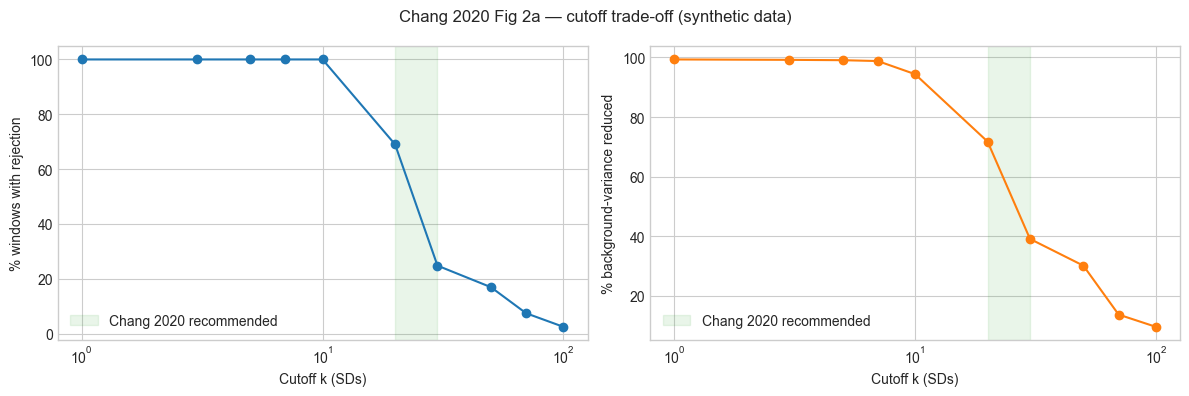

In [7]:
ks = [r["k"] for r in rows]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ks, [r["pct_windows"] for r in rows], marker="o", color="C0")
ax2.plot(ks, [r["pct_var_bg"] for r in rows], marker="o", color="C1")
for ax, ylab in [
    (ax1, "% windows with rejection"),
    (ax2, "% background-variance reduced"),
]:
    ax.set(xlabel="Cutoff k (SDs)", ylabel=ylab)
    ax.set_xscale("log")
    ax.axvspan(20, 30, color="C2", alpha=0.10, label="Chang 2020 recommended")
    ax.legend(loc="best")
fig.suptitle("Chang 2020 Fig 2a — cutoff trade-off (synthetic data)")
fig.tight_layout();

Both curves drop smoothly. The shaded **k=20-30** band — Chang's recommended setting — sits in the knee of the trade-off: aggressive enough to repair the high-amplitude bursts, lenient enough that we don't strip background EEG.

## 4. Required Pre-Processing

Kothe / Mullen 2013 state three prerequisites for ASR:

1. **High-pass filter** the data (signal mean must be zero). ASR's calibration is sensitive to slow drifts.
2. **Do not** use a common average reference before ASR — the data must be full rank.
3. **Remove obviously bad channels** (flatline channels, trigger channels, packet counters). The covariance estimate is dominated by them otherwise.

The bundled estimator emits a warning when the input has `highpass = 0 Hz`. The auto-detection of bad channels (`std > 5 × median_std`) is implemented in the validation script `scripts/run_asr_paper_validation.py` and is good practice to run before `ASR.fit_transform()`.

## 5. Related Variants in the Package

The package also exposes:

- **`ASR(method="riemannian", experimental=True)`** — the Blum et al. (2019) Riemannian variant: replaces the Euclidean covariance averaging with a Karcher mean and uses a nonlinear-eigenspace decomposition. Faster on long recordings, more aggressive on multi-channel bursts.
- **`JugglerASR(strategy="dbscan"|"gev")`** — the Kim et al. (2025) reference-selection variants that replace the window-RMS gate with a point-by-point amplitude clustering (DBSCAN) or extreme-value fit (GEV). Better at finding clean reference data in high-motion MoBI recordings.
- **`AdaptiveASR(variant="psp"|"psw")`** — Hebbian / anti-Hebbian adaptive subspace updates between successive chunks, matched against the local AASR MATLAB reference.

See `examples/asr/plot_03_adaptive_asr.py` and `plot_04_juggler_asr.py` for working snippets.

## References

1. Mullen T. R., et al. (2013) *Real-time modeling and 3D visualization of source dynamics and connectivity using wearable EEG*. IEEE EMBC.
2. Mullen T. R., et al. (2015) *Real-time neuroimaging and cognitive monitoring using wearable dry EEG*. IEEE TBME 62(11):2553-2567. doi:10.1109/TBME.2015.2481482.
3. Kothe C. *The Artifact Subspace Reconstruction Method*. SCCN technical note.
4. Chang C.-Y., Hsu S.-H., Pion-Tonachini L., Jung T.-P. (2020) *Evaluation of artifact subspace reconstruction for automatic artifact components removal in multi-channel EEG recordings*. IEEE TBME 67(4):1114-1121. doi:10.1109/TBME.2019.2930186.
5. Blum S., Jacobsen N. S. J., Bleichner M. G., Debener S. (2019) *A Riemannian modification of artifact subspace reconstruction for EEG artifact handling*. Front. Hum. Neurosci. 13:141. doi:10.3389/fnhum.2019.00141.
6. Kim H., Chang C.-Y., Kothe C., Iversen J. R., Miyakoshi M. (2025) *Juggler's ASR: Unpacking the principles of artifact subspace reconstruction for revision toward extreme MoBI*. J. Neurosci. Methods 420:110465. doi:10.1016/j.jneumeth.2025.110465.